# Workshop 04
## Por: Juan Camilo Aros Castillo

En este taller se aplicaron conceptos básicos de análisis de redes espaciales utilizando Python, con énfasis en el uso de la librería NetworkX y datos obtenidos desde OpenStreetMap mediante OSMnx. A partir de una red de bicicletas en la localidad de Barrios Unidos (Bogotá), se exploraron tareas fundamentales como el cálculo de rutas óptimas entre puntos de interés, el uso de algoritmos como Dijkstra y A*, y la integración con datos espaciales adicionales. El taller se basó en contenidos adaptados del proyecto AutoGIS, y permitió consolidar habilidades en el modelamiento, visualización y análisis de grafos en contextos geográficos.

Para su desarrollo se utilizaron las siguientes librerías:
networkx, osmnx, math, myst-nb, shapely.geometry, geopandas, matplotlib, contextily, pathlib, requests, y json.

In [1]:
conda install networkx

Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.3.1
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


El siguiente código crea y visualiza un grafo simple no dirigido con nodos, una arista y un atributo asociado a uno de los nodos.

[1, 2, 3]
[(1, 2)]


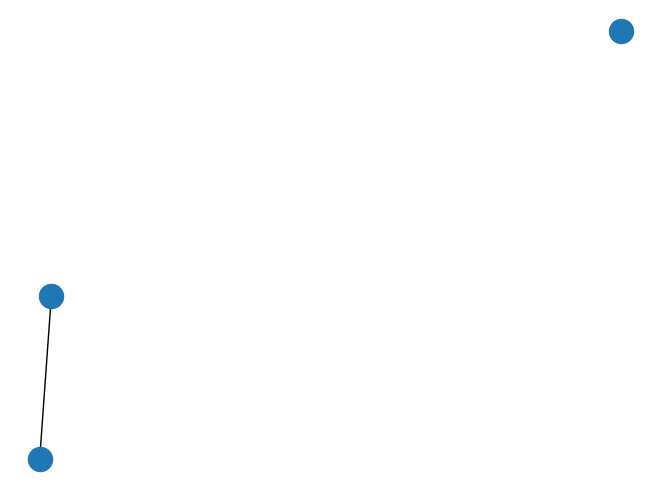

In [2]:
import networkx as nx

# Create an empty, undirected graph
G = nx.Graph()

# Add nodes and an edge
G.add_nodes_from([1, 2, 3])
G.add_edge(1, 2)

# Inspect nodes and edges
print(G.nodes())    # → [1, 2, 3]
print(G.edges())    # → [(1, 2)]

# Attach metadata
G.nodes[1]["label"] = "blue"

# Basic visualisation (requires matplotlib.pyplot as plt)
nx.draw(G)

In [3]:
!pip install osmnx

Se descarga la red de ciclorrutas de Barrios Unidos (Bogotá) desde OpenStreetMap y se genera una visualización básica del grafo con OSMnx.

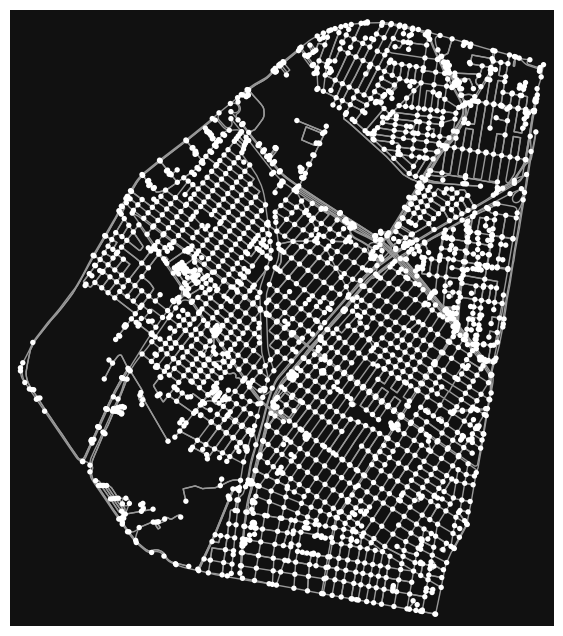

In [4]:
import osmnx

PLACE_NAME = "Barrios unidos, Bogotá, Colombia"
graph = osmnx.graph_from_place(
    PLACE_NAME,
    network_type="bike"
)
figure, ax = osmnx.plot_graph(graph)

Se define un polígono de interés a partir del nombre del lugar, se le aplica un buffer de 200 metros en un sistema de coordenadas proyectado, y luego se utiliza para descargar y visualizar la red de ciclorrutas contenida dentro de ese polígono.

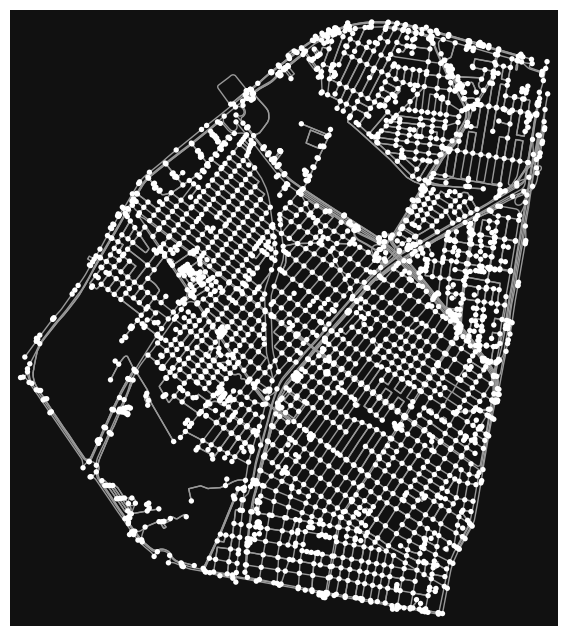

In [5]:
# Get the area of interest polygon
place_polygon = osmnx.geocode_to_gdf(PLACE_NAME)

# Re-project the polygon to a local projected CRS (so that the CRS unit is meters)
place_polygon = place_polygon.to_crs("EPSG:3067")

# Buffer by 200 meters
place_polygon["geometry"] = place_polygon.buffer(200)

# Re-project the polygon back to WGS84 (required by OSMnx)
place_polygon = place_polygon.to_crs("EPSG:4326")

# Retrieve the network graph
graph = osmnx.graph_from_polygon(
    place_polygon.at[0, "geometry"],
    network_type="bike"
)

fig, ax = osmnx.plot_graph(graph)

Se extraen únicamente las aristas (calles o conexiones) del grafo en formato de GeoDataFrame para su análisis o inspección tabular.

In [6]:
# Retrieve only edges from the graph
edges = osmnx.graph_to_gdfs(graph, nodes=False, edges=True)
edges.head()

osmid      highway lanes                name  \
u         v          key                                                     
253762065 723975752  0     45725519  residential     2           Calle 63D   
          6067062191 0    541062106        trunk     4  Avenida Carrera 30   
253762071 312656480  0     89874714  residential     2            Calle 67   
          312656101  0     89874714  residential     2            Calle 67   
          926763115  0     89875274  residential     2          Carrera 22   

                          oneway reversed      length maxspeed  \
u         v          key                                         
253762065 723975752  0     False    False    6.589048      NaN   
          6067062191 0      True    False  107.827400       60   
253762071 312656480  0     False    False   80.033867       30   
          312656101  0     False     True   68.198748       30   
          926763115  0      True    False   81.163257      NaN   

                                                                   geometry  \
u         v          key                                                      
253762065 723975752  0      LINESTRING (-74.07775 4.65561, -74.0777 4.6556)   
          6067062191 0    LINESTRING (-74.07775 4.65561, -74.07762 4.65657)   
253762071 312656480  0    LINESTRING (-74.06884 4.65751, -74.06942 4.65793)   
          312656101  0    LINESTRING (-74.06884 4.65751, -74.06832 4.65717)   
          926763115  0    LINESTRING (-74.06884 4.65751, -74.06925 4.65691)   

                         bridge junction access service width tunnel  
u         v          key                                              
253762065 723975752  0      NaN      NaN    NaN     NaN   NaN    NaN  
          6067062191 0      NaN      NaN    NaN     NaN   NaN    NaN  
253762071 312656480  0      NaN      NaN    NaN     NaN   NaN    NaN  
          312656101  0      NaN      NaN    NaN     NaN   NaN    NaN  
          926763115  0      NaN      NaN    NaN     NaN   NaN    NaN

Se realiza un conteo de frecuencia de los tipos de vía presentes en la red, según el atributo highway.

In [7]:
edges["highway"].value_counts()

highway
residential                  3226
service                      1018
tertiary                      636
secondary                     498
cycleway                      422
primary                       202
trunk                         175
pedestrian                     70
trunk_link                     42
secondary_link                 24
primary_link                    8
[service, residential]          8
unclassified                    4
[pedestrian, residential]       4
tertiary_link                   2
track                           2
[secondary_link, primary]       1
[primary, primary_link]         1
Name: count, dtype: int64

Se reproyecta el grafo a un sistema de coordenadas en metros (UTM) y se convierten sus nodos y aristas en GeoDataFrames, conservando la referencia espacial asociada.

In [8]:
# Transform the graph to UTM
graph = osmnx.project_graph(graph) 

# Extract reprojected nodes and edges
nodes, edges = osmnx.graph_to_gdfs(graph)

nodes.crs

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Se calculan estadísticas básicas del grafo, como el número de nodos, aristas, densidad, longitud total de la red, y otras métricas estructurales de la red vial.

In [9]:
# Calculate network statistics
osmnx.basic_stats(graph)

{'n': 2881,
 'm': 6343,
 'k_avg': 4.403332176327664,
 'edge_length_total': 453896.42224316543,
 'edge_length_avg': 71.55863506907858,
 'streets_per_node_avg': 3.099618188129122,
 'streets_per_node_counts': {0: 0,
  1: 374,
  2: 6,
  3: 1479,
  4: 1005,
  5: 15,
  6: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.1298160360985769,
  2: 0.0020826102047900035,
  3: 0.5133634154807358,
  4: 0.3488372093023256,
  5: 0.0052065255119750084,
  6: 0.0006942034015966678},
 'intersection_count': 2507,
 'street_length_total': 322413.0732339498,
 'street_segment_count': 4387,
 'street_length_avg': 73.49283638795299,
 'circuity_avg': 1.037430971006176,
 'self_loop_proportion': 0.0013676772281741509}

Se calcula la envolvente convexa (convex hull) de todas las aristas del grafo, generando un polígono mínimo que encierra completamente la red.

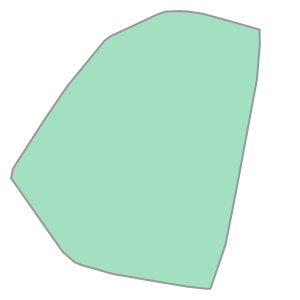

In [10]:
convex_hull = edges.geometry.union_all().convex_hull
convex_hull

Se recalculan las estadísticas básicas del grafo, esta vez incorporando el área de la envolvente convexa para obtener métricas como la densidad de la red por unidad de superficie.

In [11]:
stats = osmnx.basic_stats(graph, area=convex_hull.area)
stats

{'n': 2881,
 'm': 6343,
 'k_avg': 4.403332176327664,
 'edge_length_total': 453896.42224316543,
 'edge_length_avg': 71.55863506907858,
 'streets_per_node_avg': 3.099618188129122,
 'streets_per_node_counts': {0: 0,
  1: 374,
  2: 6,
  3: 1479,
  4: 1005,
  5: 15,
  6: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.1298160360985769,
  2: 0.0020826102047900035,
  3: 0.5133634154807358,
  4: 0.3488372093023256,
  5: 0.0052065255119750084,
  6: 0.0006942034015966678},
 'intersection_count': 2507,
 'street_length_total': 322413.0732339498,
 'street_segment_count': 4387,
 'street_length_avg': 73.49283638795299,
 'circuity_avg': 1.037430971006176,
 'self_loop_proportion': 0.0013676772281741509,
 'node_density_km': 230.81835268222042,
 'intersection_density_km': 200.85442907821124,
 'edge_density_km': 36365.02064231899,
 'street_density_km': 25830.91095004248}

### 2.1. 🚀 **Now it’s your turn! — Exploring street attributes**

1. **Calculate** the total length of streets classified as `residential`, `primary`, and `secondary`.  
2. **Compare** the mean length for each class.  
3. **Visualise** the five longest street classes in a bar chart.

> 💡 *Hint:* `edges.groupby("highway")["length"].sum()` followed by `.sort_values()` will help.

Se convierten los valores de la columna highway a texto y se filtran las calles de tipo "residential", "primary" y "secondary" para calcular la longitud total de red por cada tipo seleccionado.

In [14]:
edges["highway"] = edges["highway"].astype(str) 
selected_highways = ["residential", "primary", "secondary"]
total_length_by_type = edges[edges["highway"].isin(selected_highways)] \
    .groupby("highway")["length"].sum()
print("Longitud total por tipo de calle:")
print(total_length_by_type)

Longitud total por tipo de calle:
highway
primary         17431.589593
residential    226663.118405
secondary       38745.692251
Name: length, dtype: float64


Se calcula la longitud media de las calles para cada tipo de vía seleccionado ("residential", "primary", "secondary"), agrupando por el atributo highway.

In [16]:
mean_length_by_type = edges[edges["highway"].isin(selected_highways)] \
    .groupby("highway")["length"].mean()

print("\nLongitud media por tipo de calle:")
print(mean_length_by_type)


Longitud media por tipo de calle:
highway
primary        86.294998
residential    70.261351
secondary      77.802595
Name: length, dtype: float64


Se visualizan las cinco clases de calles más extensas en la red mediante un gráfico de barras, ordenadas por longitud total y agrupadas según el tipo de vía (highway).

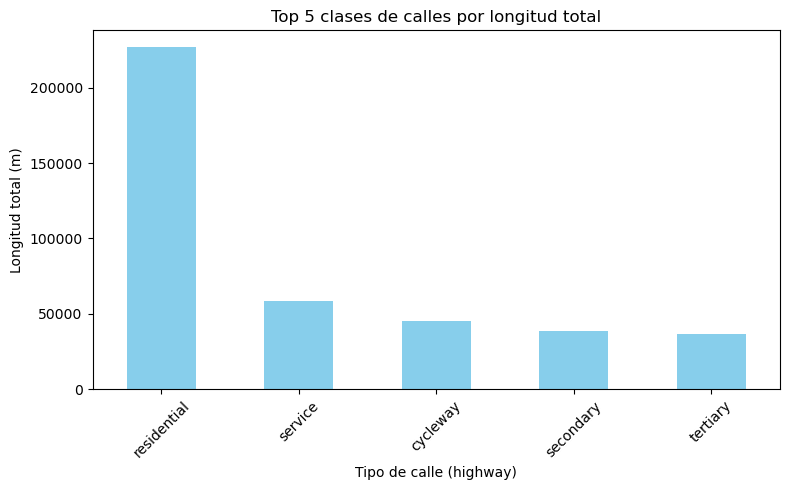

In [17]:
import matplotlib.pyplot as plt
total_length_all = edges.groupby("highway")["length"].sum().sort_values(ascending=False)
top5 = total_length_all.head(5)
top5.plot(kind="bar", figsize=(8,5), color="skyblue")
plt.title("Top 5 clases de calles por longitud total")
plt.xlabel("Tipo de calle (highway)")
plt.ylabel("Longitud total (m)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La gráfica muestra que las calles de tipo **residential** conforman, por amplio margen, la mayor parte de la longitud total de la red vial en Barrios Unidos. Le siguen en proporción las vías **service**, **cycleway**, **secondary** y **tertiary**, lo que indica que el tejido urbano del área está dominado por calles locales y de servicio, con una presencia relevante de ciclorrutas. Esto sugiere una estructura vial orientada al tránsito interno y de proximidad, más que al transporte de alta capacidad.

Se extraen y redondean dos métricas clave de la red —la densidad de nodos por kilómetro cuadrado (node_density_km) y la longitud total de aristas en kilómetros (edge_length_total)— para integrarlas como variables dinámicas dentro del documento utilizando myst_nb.glue.

In [13]:
import math
import myst_nb

myst_nb.glue("node_density_km", round(stats["node_density_km"], 1))
myst_nb.glue("edge_length_total", math.floor(stats["edge_length_total"] / 1000))

230.8

453

Se obtienen las coordenadas de los puntos de origen y destino a partir de sus nombres mediante geocodificación, se transforman al mismo sistema de referencia espacial que las aristas (UTM) y se extraen como centroides para ser utilizados en el cálculo de rutas sobre la red.

In [14]:
origin = (
    osmnx.geocode_to_gdf("parque de los novios, bogota")  # fetch geolocation
    .to_crs(edges.crs)  # transform to UTM
    .at[0, "geometry"]  # pick geometry of first row
    .centroid  # use the centre point
)

destination = (
    osmnx.geocode_to_gdf("parque la castellana, bogota")
    .to_crs(edges.crs)
    .at[0, "geometry"]
    .centroid
)

Se identifica el nodo más cercano al punto de origen dentro del grafo, con base en sus coordenadas proyectadas, para usarlo como punto inicial en el cálculo de rutas.

In [15]:
origin_node_id = osmnx.nearest_nodes(graph, origin.x, origin.y)
origin_node_id

6827353353

Se localiza el nodo más cercano al punto de destino en la red, lo que permite establecer el punto final para el cálculo de rutas sobre el grafo.

In [16]:
destination_node_id = osmnx.nearest_nodes(graph, destination.x, destination.y)
destination_node_id

9409815436

Se calcula la ruta más corta entre el nodo de origen y el nodo de destino dentro del grafo, utilizando la distancia (`length`) como criterio de optimización por defecto. El resultado es una lista ordenada de identificadores de nodos que conforman el camino óptimo.

In [17]:
# Find the shortest path between origin and destination
route = osmnx.shortest_path(graph, origin_node_id, destination_node_id)
route

[6827353353,
 2374398079,
 9412674180,
 2374398041,
 267031837,
 267031833,
 722828543,
 722852549,
 722852547,
 722828499,
 267032207,
 6965090045,
 6965090047,
 3521592924,
 267032195,
 267021491,
 267021501,
 266893819,
 267021534,
 266893799,
 266893755,
 266893761,
 5750272638,
 5750272639,
 266893765,
 1052514609,
 1892456280,
 1892456296,
 1052514600,
 1833695805,
 320321930,
 1642693965,
 9546749598,
 1833695809,
 373424878,
 1052514612,
 373424838,
 373424977,
 373424918,
 373424947,
 373425038,
 373425003,
 382802775,
 1012808054,
 5115993375,
 382802770,
 373425817,
 10074986969,
 10074986963,
 382802768,
 382802758,
 316847024,
 311453417,
 12007343172,
 1367029571,
 1367029563,
 4913780072,
 505075672,
 505075650,
 505075642,
 505075639,
 505075632,
 947760898,
 505075606,
 745803389,
 885733664,
 316254516,
 867345301,
 262390999,
 6070129541,
 9374035694,
 9429162517,
 9429162519,
 316254446,
 9362584859,
 9409815436]

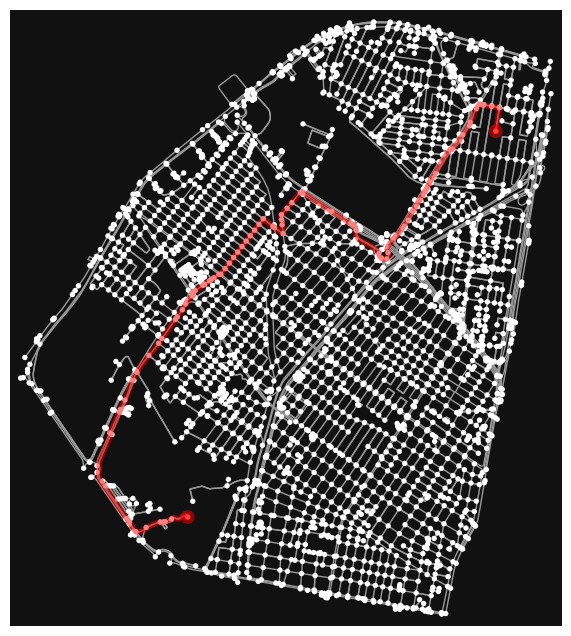

In [18]:
# Plot the shortest path
fig, ax = osmnx.plot_graph_route(graph, route)

### 3.4. 🚀 **Now it’s your turn! — Alternative routes**

1. **Calculate** a second route that avoids `motorway` and `trunk` streets.  
2. **Compare** its length with the original shortest route.  
3. **Discuss** in one sentence why constrained routes can be useful for certain users.

> 💡 You can filter `edges` before building a sub-graph or use `osmnx.utils_graph.get_route_edge_attributes`.

En este ejercicio se calcula la ruta más corta entre el Parque de los Novios y el Parque La Castellana, dentro de la red de ciclorrutas de la localidad de Barrios Unidos (Bogotá), utilizando datos de OpenStreetMap. Se comparan dos rutas: una original que considera toda la red disponible, y una alternativa que excluye vías clasificadas como motorway y trunk, comúnmente no aptas para el tránsito ciclista. Ambas rutas se obtienen mediante el algoritmo de menor distancia ponderado por longitud, y su comparación permite evaluar cómo influyen las restricciones viales en la planificación de rutas más seguras o accesibles para ciclistas.

In [32]:
import osmnx as ox
import networkx as nx

# Función para calcular longitud de una ruta
def calcular_longitud_ruta(G, ruta):
    longitud = 0
    for u, v in zip(ruta[:-1], ruta[1:]):
        datos = G.get_edge_data(u, v)
        if datos:
            datos_arista = datos[list(datos.keys())[0]]
            longitud += datos_arista.get('length', 0)
    return longitud

# Descargar grafo de bicicletas
PLACE_NAME = "Barrios unidos, Bogotá, Colombia"
graph = ox.graph_from_place(PLACE_NAME, network_type="bike")

# Definir puntos de origen y destino usando direcciones
origin_point = ox.geocode_to_gdf("parque de los novios, bogota").at[0, "geometry"].centroid
destination_point = ox.geocode_to_gdf("parque la castellana, bogota").at[0, "geometry"].centroid

# Buscar nodos más cercanos
orig_node = ox.distance.nearest_nodes(graph, origin_point.x, origin_point.y)
dest_node = ox.distance.nearest_nodes(graph, destination_point.x, destination_point.y)

# Ruta original
ruta_original = nx.shortest_path(graph, orig_node, dest_node, weight='length')
longitud_original = calcular_longitud_ruta(graph, ruta_original)

# Crear subgrafo sin 'motorway' ni 'trunk'
nodes_all, _ = ox.graph_to_gdfs(graph)
edges_all = ox.graph_to_gdfs(graph, nodes=False, edges=True)
edges_filtradas = edges_all[~edges_all['highway'].isin(['motorway', 'trunk'])]
G_filtrado = ox.graph_from_gdfs(nodes_all, edges_filtradas)

# Ruta alternativa
ruta_alternativa = nx.shortest_path(G_filtrado, orig_node, dest_node, weight='length')
longitud_alternativa = calcular_longitud_ruta(G_filtrado, ruta_alternativa)

Se imprimen las longitudes de la ruta original y la alternativa (sin vías tipo `motorway` ni `trunk`) en metros, y se visualizan ambas sobre el grafo utilizando colores diferentes para facilitar su comparación espacial.

Ruta original: 6468.55 metros
Ruta alternativa (sin 'motorway' ni 'trunk'): 6468.55 metros


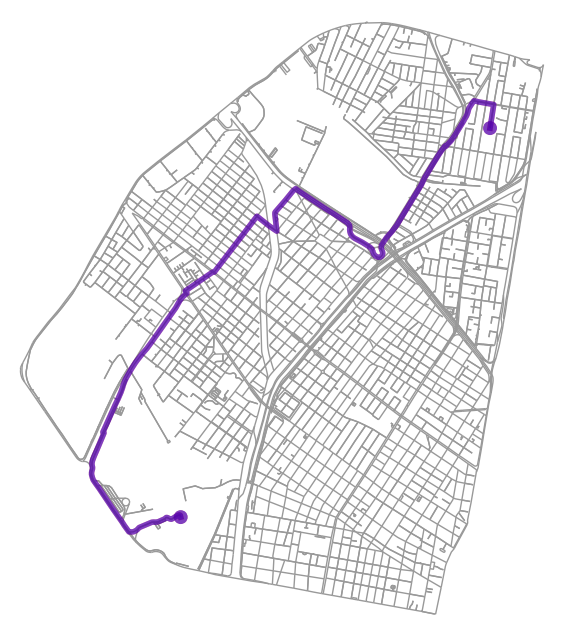

In [33]:
print(f"Ruta original: {longitud_original:.2f} metros")
print(f"Ruta alternativa (sin 'motorway' ni 'trunk'): {longitud_alternativa:.2f} metros")

# Graficar rutas
fig, ax = ox.plot_graph_routes(
    graph,
    [ruta_original, ruta_alternativa],
    route_colors=["red", "blue"],
    route_linewidth=3,
    node_size=0,
    bgcolor='white'
)


Se define una función para identificar los tipos de vía (highway) utilizados en una ruta. Al aplicarla sobre la ruta original y la ruta filtrada, se obtiene un conjunto con las clases de calles recorridas en cada caso, lo que permite comparar si las restricciones aplicadas realmente modificaron la selección de vías en la red.

In [34]:
# Extraer atributos de la ruta original
def tipos_de_via_en_ruta(G, ruta):
    tipos = []
    for u, v in zip(ruta[:-1], ruta[1:]):
        datos = G.get_edge_data(u, v)
        if datos:
            datos_arista = datos[list(datos.keys())[0]]
            tipo = datos_arista.get('highway', 'desconocido')
            tipos.append(tipo)
    return tipos

tipos_original = tipos_de_via_en_ruta(graph, ruta_original)
tipos_filtrada = tipos_de_via_en_ruta(G_filtrado, ruta_alternativa)

print("Tipos de vía en ruta original:", set(tipos_original))
print("Tipos de vía en ruta filtrada:", set(tipos_filtrada))


Tipos de vía en ruta original: {'track', 'primary', 'cycleway', 'service', 'residential', 'secondary', 'tertiary'}
Tipos de vía en ruta filtrada: {'track', 'primary', 'cycleway', 'service', 'residential', 'secondary', 'tertiary'}


En este análisis, la comparación entre la ruta más corta y una ruta alternativa restringida para evitar vías clasificadas como motorway y trunk no mostró diferencias significativas en longitud ni trayectoria. Esto sugiere que, al trabajar con redes viales construidas con network_type="bike", OSMnx ya excluye de forma predeterminada aquellas vías no aptas para bicicletas. Por tanto, las rutas generadas respetan desde el inicio criterios de seguridad y accesibilidad, lo que puede ser especialmente útil para estudios de movilidad sostenible sin necesidad de filtros adicionales. Sin embargo, en entornos con una red vial más diversa o en análisis con network_type="all", estos filtros podrían tener un mayor impacto en los resultados.

In [19]:
# Get the nodes along the shortest path
route_nodes = nodes.loc[route]
route_nodes

,y,x,street_count,highway,geometry
osmid,,,,,
6827353353,514730.164347,601816.779143,1,NaN,POINT (601816.779 514730.164)
2374398079,514716.575927,601696.465918,3,NaN,POINT (601696.466 514716.576)
9412674180,514695.342878,601648.407727,3,NaN,POINT (601648.408 514695.343)
2374398041,514692.392772,601632.627001,3,NaN,POINT (601632.627 514692.393)
267031837,514692.795498,601610.729983,3,NaN,POINT (601610.73 514692.795)
...,...,...,...,...,...
9429162517,517833.545603,604028.775943,3,NaN,POINT (604028.776 517833.546)
9429162519,517829.520454,604044.532068,4,NaN,POINT (604044.532 517829.52)
316254446,517818.699799,604104.199721,4,traffic_signals,POINT (604104.2 517818.7)


Se construye una geometría tipo LineString a partir de los puntos que conforman la ruta más corta, utilizando las coordenadas de los nodos. Esta geometría es útil para visualizar, exportar o realizar análisis espaciales sobre la trayectoria recorrida.

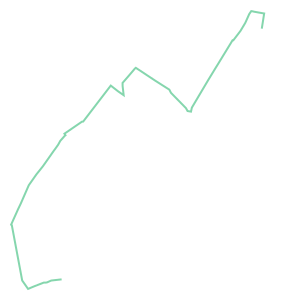

In [20]:
import shapely.geometry

# Create a geometry for the shortest path
route_line = shapely.geometry.LineString(
    list(route_nodes.geometry.values)
)
route_line

Se crea un `GeoDataFrame` que contiene la geometría de la ruta (`LineString`) y la lista de nodos que la componen, asignándole el mismo sistema de referencia espacial que la red. Además, se calcula la longitud total de la ruta en metros mediante la propiedad `length`. Este objeto es útil para análisis, visualización o exportación a formatos geoespaciales.


In [21]:
import geopandas

route_geom = geopandas.GeoDataFrame(
    {
        "geometry": [route_line],
        "osm_nodes": [route],
    },
    crs=edges.crs
)

# Calculate the route length
route_geom["length_m"] = route_geom.length

route_geom.head()

,geometry,osm_nodes,length_m
0,"LINESTRING (601816.779 514730.164, 601696.466 ...","[6827353353, 2374398079, 9412674180, 237439804...",6303.880866


Se descargan todos los elementos etiquetados como `building` desde OpenStreetMap para el área definida por `PLACE_NAME`, y se reproyectan al mismo sistema de coordenadas que la red vial (`edges.crs`) para garantizar compatibilidad en análisis espaciales.

In [22]:
buildings = osmnx.features_from_place(
    PLACE_NAME,
    {
        "building" : True
    }
).to_crs(edges.crs)

In [23]:
conda install matplotlib

Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.3.1
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


Se genera un mapa temático que combina la red vial (nodos y aristas), los edificios del área de estudio y la ruta calculada, todo sobre un fondo cartográfico proporcionado por `contextily`. Esto permite visualizar de forma integrada la infraestructura urbana y la trayectoria recorrida, facilitando la interpretación espacial del análisis de rutas.

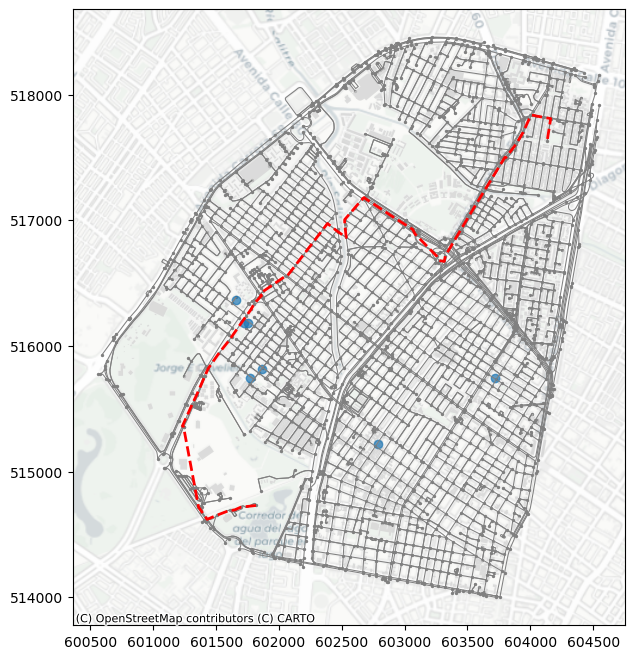

In [25]:
import contextily
import matplotlib.pyplot

fig, ax = matplotlib.pyplot.subplots(figsize=(12,8))

# Plot edges and nodes
edges.plot(ax=ax, linewidth=0.75, color='gray')
nodes.plot(ax=ax, markersize=2, color='gray')

# Add buildings
ax = buildings.plot(ax=ax, facecolor='lightgray', alpha=0.7)

# Add the route
ax = route_geom.plot(ax=ax, linewidth=2, linestyle='--', color='red')

# Add basemap
contextily.add_basemap(ax, crs=buildings.crs, source=contextily.providers.CartoDB.Positron)

In [26]:
edges.head()

osmid      highway lanes                name  \
u         v          key                                                     
253762065 723975752  0     45725519  residential     2           Calle 63D   
          6067062191 0    541062106        trunk     4  Avenida Carrera 30   
723975752 253762065  0     45725519  residential     2           Calle 63D   
          983036685  0     58293679     cycleway   NaN                 NaN   
          9235777159 0     45725519  residential     2           Calle 63D   

                          oneway reversed      length maxspeed  \
u         v          key                                         
253762065 723975752  0     False    False    6.589048      NaN   
          6067062191 0      True    False  107.827400       60   
723975752 253762065  0     False     True    6.589048      NaN   
          983036685  0     False    False   96.326218      NaN   
          9235777159 0     False    False   46.674227      NaN   

                                                                   geometry  \
u         v          key                                                      
253762065 723975752  0    LINESTRING (602290.859 514662.627, 602297.372 ...   
          6067062191 0    LINESTRING (602290.859 514662.627, 602305.562 ...   
723975752 253762065  0    LINESTRING (602297.372 514661.597, 602290.859 ...   
          983036685  0    LINESTRING (602297.372 514661.597, 602287.069 ...   
          9235777159 0    LINESTRING (602297.372 514661.597, 602301.177 ...   

                         bridge junction access service width tunnel  
u         v          key                                              
253762065 723975752  0      NaN      NaN    NaN     NaN   NaN    NaN  
          6067062191 0      NaN      NaN    NaN     NaN   NaN    NaN  
723975752 253762065  0      NaN      NaN    NaN     NaN   NaN    NaN  
          983036685  0      NaN      NaN    NaN     NaN   NaN    NaN  
          9235777159 0      NaN      NaN    NaN     NaN   NaN    NaN

Se identifican columnas del GeoDataFrame `edges` que podrían contener valores inconsistentes o variados en su formato, y se convierten explícitamente a tipo `string` para estandarizar su contenido y evitar errores en operaciones posteriores como agrupamientos, filtrados o exportaciones.

In [27]:
# Columns with invalid values
problematic_columns = [
    "osmid",
    "lanes",
    "name",
    "highway",
    "width",
    "maxspeed",
    "reversed",
    "junction",
    "bridge",
    "tunnel",
    "access",
    "service",
    
]

#  convert selected columns to string format
edges[problematic_columns] = edges[problematic_columns].astype(str)

In [28]:
route_geom["osm_nodes"] = route_geom["osm_nodes"].astype(str)

In [29]:
conda install pathlib

Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.3.1
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


Se define la ruta del directorio actual donde se encuentra el notebook (`NOTEBOOK_PATH`) y se crea una subcarpeta llamada `"data"` dentro de él. Si la carpeta ya existe, no se genera error. Esta estructura permite organizar y guardar archivos de salida del análisis, como rutas, edificios o mapas exportados.

In [30]:
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data"
DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)

### 🚀 **Now it’s your turn! — Extending your analysis**

1. **Create** a 50 m buffer around the route and select buildings intersecting it.  
2. **Count** buildings both in total and by `building` tag within this corridor.  
3. **Export** the result to `buildings_along_route.geojson`.  

> 💡 Try `buildings[buildings.intersects(buffer)]` or a spatial overlay with GeoPandas.


Se realiza la descarga de una red de ciclorrutas para Barrios Unidos (Bogotá) y calcula la ruta más corta entre dos puntos de interés: el Parque de los Novios y el Parque La Castellana. A partir de esa ruta, se genera un buffer de 50 metros y se consulta la Overpass API para obtener los edificios dentro de esa zona. El resultado es una estructura en formato JSON que contiene las geometrías y atributos de los elementos tipo building que intersectan el área de análisis.

In [43]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import LineString
import requests

PLACE_NAME = "Barrios Unidos, Bogotá, Colombia"
graph = ox.graph_from_place(PLACE_NAME, network_type="bike")

origin = ox.geocode_to_gdf("parque de los novios, bogota").at[0, 'geometry'].centroid
destination = ox.geocode_to_gdf("parque la castellana, bogota").at[0, 'geometry'].centroid

orig_node = ox.distance.nearest_nodes(graph, origin.x, origin.y)
dest_node = ox.distance.nearest_nodes(graph, destination.x, destination.y)

ruta = ox.shortest_path(graph, orig_node, dest_node, weight='length')
coords = [(graph.nodes[n]['x'], graph.nodes[n]['y']) for n in ruta]
linea = LineString(coords)
ruta_gdf = gpd.GeoDataFrame(geometry=[linea], crs='EPSG:4326')

buffer = ruta_gdf.to_crs(epsg=3857).buffer(50).to_crs(epsg=4326)

minx, miny, maxx, maxy = buffer.total_bounds

query = f"""
[out:json][timeout:25];
(
  way["building"]({miny},{minx},{maxy},{maxx});
);
out geom;
"""
response = requests.get("http://overpass-api.de/api/interpreter", params={'data': query})
data = response.json()

Se convierte la respuesta JSON de Overpass en un `GeoDataFrame`, extrayendo los edificios como polígonos válidos a partir de sus coordenadas. Luego, se filtran aquellos que intersectan el buffer de 50 metros alrededor de la ruta calculada. Finalmente, se imprime el número total de edificios encontrados en esa zona y un conteo por tipo de edificio según el atributo `building`.

In [45]:
from shapely.geometry import Polygon

features = []
for el in data['elements']:
    if 'geometry' in el:
        coords = [(pt['lon'], pt['lat']) for pt in el['geometry']]
        if len(coords) >= 3:
            polygon = Polygon(coords)
            if polygon.is_valid:
                features.append({
                    'geometry': polygon,
                    'building': el['tags'].get('building', 'unknown')
                })

buildings_gdf = gpd.GeoDataFrame(features, crs='EPSG:4326')

buildings_in_buffer = buildings_gdf[buildings_gdf.intersects(buffer.iloc[0])]

print(f" Total edificios en el buffer: {len(buildings_in_buffer)}")
print(" Conteo por tipo de edificio:")
print(buildings_in_buffer['building'].value_counts())

 Total edificios en el buffer: 240
 Conteo por tipo de edificio:
building
yes             226
apartments        5
roof              4
school            2
construction      2
residential       1
Name: count, dtype: int64


In [46]:
# Exportar a GeoJSON
buildings_in_buffer.to_file("buildings_along_route.geojson", driver="GeoJSON")
print("✅ Exportado como 'buildings_along_route.geojson'")

✅ Exportado como 'buildings_along_route.geojson'


Se descarga la red de ciclorrutas correspondiente a la localidad de Barrios Unidos en Bogotá desde OpenStreetMap, utilizando el parámetro `network_type="bike"` para obtener únicamente aquellas vías aptas para tránsito en bicicleta. Esta red es representada como un grafo dirigido con atributos espaciales y topológicos.

In [47]:
import osmnx as ox
import networkx as nx
from shapely.geometry import Point
import math

PLACE_NAME = "Barrios Unidos, Bogotá, Colombia"
graph = ox.graph_from_place(PLACE_NAME, network_type="bike")

Se geocodifican las direcciones del Parque de los Novios y el Parque La Castellana para obtener sus ubicaciones como puntos geométricos. Luego, se identifican los nodos más cercanos a estos puntos dentro del grafo, los cuales servirán como nodos de inicio y destino para el cálculo de rutas.

In [48]:
origen = ox.geocode_to_gdf("parque de los novios, bogota").at[0, 'geometry'].centroid
destino = ox.geocode_to_gdf("parque la castellana, bogota").at[0, 'geometry'].centroid

nodo_origen = ox.distance.nearest_nodes(graph, origen.x, origen.y)
nodo_destino = ox.distance.nearest_nodes(graph, destino.x, destino.y)

Se define una función de heurística para el algoritmo A\*, basada en la fórmula del **haversine**, que estima la distancia geodésica (en metros) entre dos nodos del grafo a partir de sus coordenadas. Esta estimación actúa como un valor mínimo del costo restante hacia el destino y permite que A\* priorice los nodos más prometedores, mejorando la eficiencia del cálculo de rutas.


In [49]:
def heuristica(u, v):
    x1, y1 = graph.nodes[u]['x'], graph.nodes[u]['y']
    x2, y2 = graph.nodes[v]['x'], graph.nodes[v]['y']
    R = 6371000  # radio tierra en metros
    phi1, phi2 = math.radians(y1), math.radians(y2)
    dphi = math.radians(y2 - y1)
    dlambda = math.radians(x2 - x1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

Se calcula la ruta más corta entre el nodo de origen y el de destino utilizando el algoritmo A\*, con la heurística de distancia geodésica definida previamente y la longitud de las vías (`length`) como peso. Luego, se visualiza la ruta resultante sobre el grafo con una línea púrpura que resalta el recorrido óptimo.


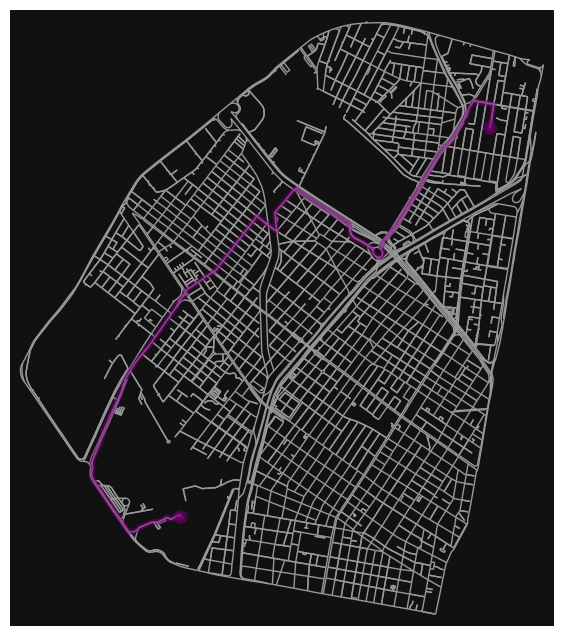

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [50]:
ruta_astar = nx.astar_path(graph, nodo_origen, nodo_destino, heuristic=heuristica, weight='length')

ox.plot_graph_route(graph, ruta_astar, route_color="purple", route_linewidth=4, node_size=0)

La comparación muestra que tanto el algoritmo A\* como Dijkstra generaron una ruta con la misma cantidad de nodos (76), lo cual confirma que, al usar la misma red y función de costo (`length`), ambos algoritmos encuentran la misma ruta óptima. La principal diferencia entre ellos radica en la eficiencia del cálculo, no en el resultado final cuando se usa una heurística admisible.

In [51]:
ruta_dijkstra = nx.shortest_path(graph, nodo_origen, nodo_destino, weight='length')
print("A* vs Dijkstra (longitud nodos):", len(ruta_astar), "vs", len(ruta_dijkstra))

A* vs Dijkstra (longitud nodos): 76 vs 76


## Conclusión
Al aplicar los algoritmos de Dijkstra y A* sobre la red de bicicletas de Barrios Unidos para calcular la ruta más corta entre el Parque de los Novios y el Parque La Castellana, ambos algoritmos generaron exactamente la misma ruta. Esto se debe a que ambos modelos buscan caminos óptimos en grafos ponderados y, en este caso, se usó la misma función de costo basada en la longitud real de las vías (length). Además, la heurística utilizada por A* fue admisible, es decir, no sobreestimó el costo entre nodos, lo cual garantiza que A* también encuentre la ruta más corta. En grafos como los extraídos de OpenStreetMap, donde los pesos están bien definidos y no se aplican restricciones adicionales, A* y Dijkstra tienden a producir resultados idénticos, diferenciándose solo en su eficiencia computacional en redes grandes.